# Parallel scaling and local numerical validation

This notebook documents the strong scaling of the CPU implementation and validates every server result against a previously computed local reference. It only loads existing `.npz` files and uses the supplied benchmark times; it does not recompute any Gondolo-Silk profile.

## Computational context

The benchmarks were run on `serverpucp` with Ubuntu 22.04.1 LTS (`x86_64`), two Intel Xeon Platinum 8358 sockets (32 physical cores per socket, 64 physical cores and 128 logical CPUs in total), two NUMA nodes, and approximately 377 GiB of RAM. Four NVIDIA A16 GPUs were present but were not used.

The server environment used CPython 3.10.12, NumPy 2.2.6, and SciPy 1.15.3. Parallel work was dispatched with `ProcessPoolExecutor`. Before importing NumPy and SciPy, the script used `setdefault(..., "1")` for `OMP_NUM_THREADS`, `OPENBLAS_NUM_THREADS`, `MKL_NUM_THREADS`, and `NUMEXPR_NUM_THREADS` to reduce oversubscription risk.

The server was shared during these measurements. Other processes were active and the observed load average was approximately 52-58, so these are empirical measurements under concurrent load rather than dedicated-machine benchmarks.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.labelsize": 11, "axes.titlesize": 12})

G = 4.30091e-3       # pc (km/s)^2 / Msun
C_LIGHT = 299792.458 # km/s
M = 2.6e6            # Msun
R_S = 2.0 * G * M / C_LIGHT**2

def display_markdown_table(headers, rows):
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

print(f"Schwarzschild radius: {R_S:.12e} pc")

Schwarzschild radius: 2.488412031342e-07 pc


## Part A - Strong scaling

Every run used `gamma_values = np.array([0.5, 1.0, 1.5])`, 200 radial points per cuspidal profile, and 200 points for the isothermal profile. Only the worker count changed. The one-worker run still uses `ProcessPoolExecutor(max_workers=1)`, so it is the one-worker baseline of the multiprocessing implementation.

The derived quantities are calculated below rather than entered manually:

$$S(N)=\frac{T_1}{T_N}, \qquad E(N)=\frac{S(N)}{N}.$$

In [2]:
workers = np.array([1, 8, 16, 32], dtype=int)
gamma_values_benchmark = np.array([0.5, 1.0, 1.5])
gamma_runtimes = np.array([
    [1064.846, 1041.701, 702.164],
    [149.326, 145.046, 98.427],
    [89.231, 97.848, 71.505],
    [61.263, 56.971, 43.125],
])
total_runtimes = np.array([2810.472, 394.534, 260.417, 163.098])

speedup = total_runtimes[0] / total_runtimes
parallel_efficiency = speedup / workers
ideal_runtime = total_runtimes[0] / workers

scaling_rows = [
    [int(n), f"{runtime:.3f}", f"{s:.4f}", f"{e:.2%}"]
    for n, runtime, s, e in zip(workers, total_runtimes, speedup, parallel_efficiency)
]
display_markdown_table(
    ["Workers", "Runtime [s]", "Speedup", "Parallel efficiency"],
    scaling_rows,
)

| Workers | Runtime [s] | Speedup | Parallel efficiency |
| --- | --- | --- | --- |
| 1 | 2810.472 | 1.0000 | 100.00% |
| 8 | 394.534 | 7.1235 | 89.04% |
| 16 | 260.417 | 10.7922 | 67.45% |
| 32 | 163.098 | 17.2318 | 53.85% |

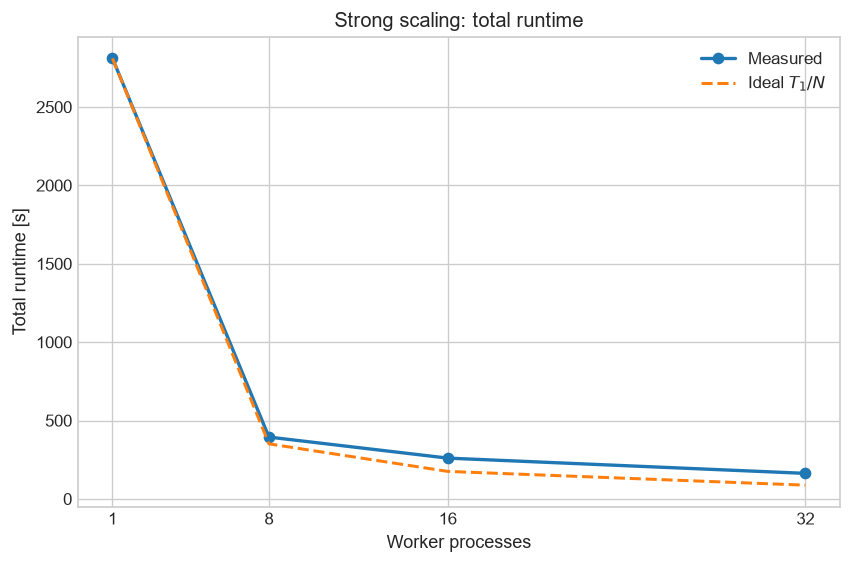

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(workers, total_runtimes, "o-", linewidth=2, label="Measured")
ax.plot(workers, ideal_runtime, "--", linewidth=1.8, label=r"Ideal $T_1/N$")
ax.set_xticks(workers)
ax.set_xlabel("Worker processes")
ax.set_ylabel("Total runtime [s]")
ax.set_title("Strong scaling: total runtime")
ax.legend()
fig.tight_layout()
plt.show()

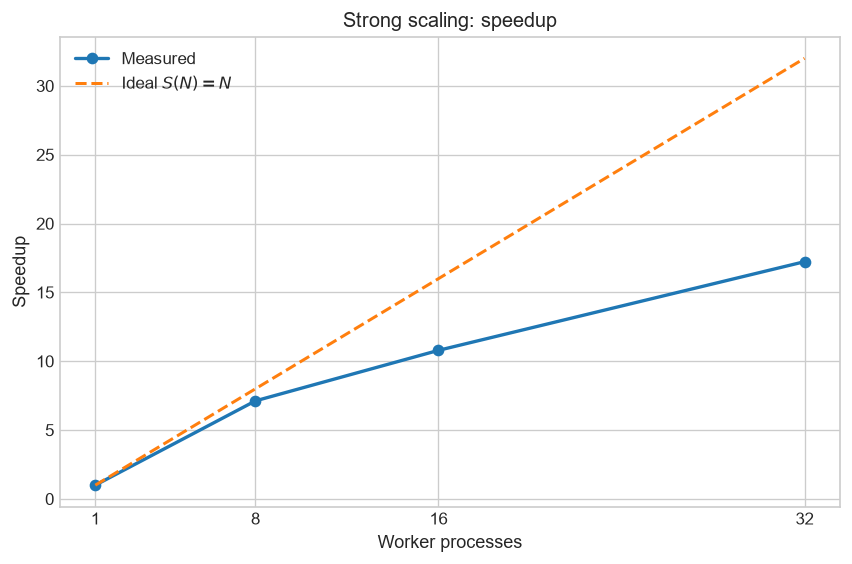

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(workers, speedup, "o-", linewidth=2, label="Measured")
ax.plot(workers, workers, "--", linewidth=1.8, label=r"Ideal $S(N)=N$")
ax.set_xticks(workers)
ax.set_xlabel("Worker processes")
ax.set_ylabel("Speedup")
ax.set_title("Strong scaling: speedup")
ax.legend()
fig.tight_layout()
plt.show()

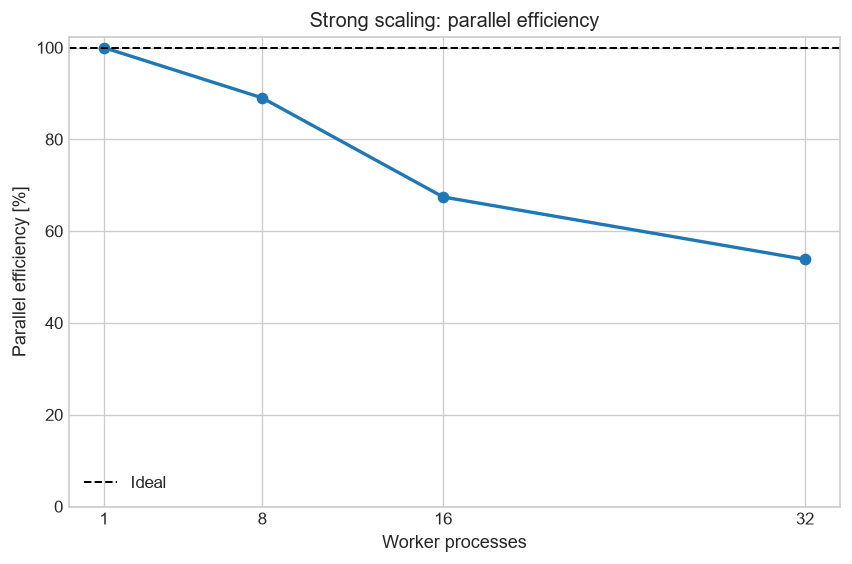

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(workers, 100.0 * parallel_efficiency, "o-", linewidth=2)
ax.axhline(100.0, color="black", linestyle="--", linewidth=1.2, label="Ideal")
ax.set_xticks(workers)
ax.set_xlabel("Worker processes")
ax.set_ylabel("Parallel efficiency [%]")
ax.set_title("Strong scaling: parallel efficiency")
ax.set_ylim(bottom=0)
ax.legend()
fig.tight_layout()
plt.show()

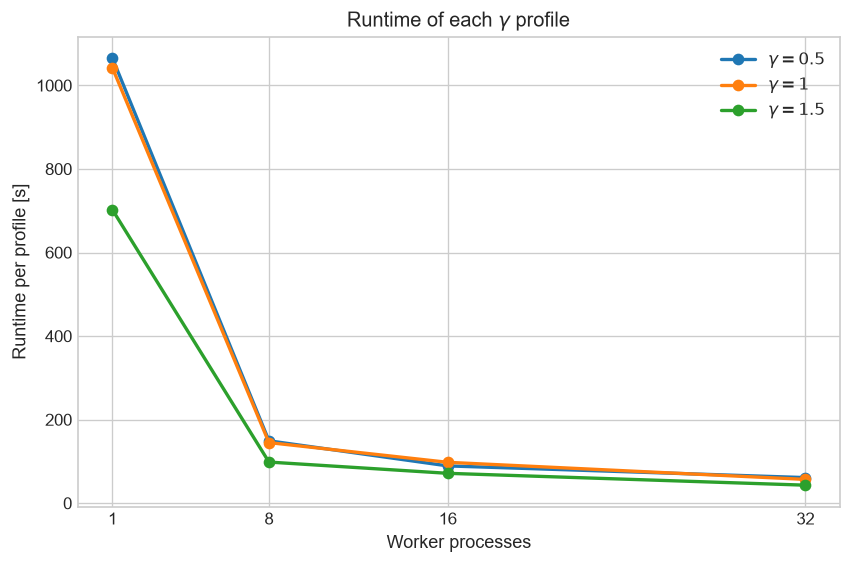

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for index, gamma in enumerate(gamma_values_benchmark):
    ax.plot(
        workers,
        gamma_runtimes[:, index],
        "o-",
        linewidth=2,
        label=fr"$\gamma={gamma:g}$",
    )
ax.set_xticks(workers)
ax.set_xlabel("Worker processes")
ax.set_ylabel("Runtime per profile [s]")
ax.set_title(r"Runtime of each $\gamma$ profile")
ax.legend()
fig.tight_layout()
plt.show()

The timing curves include the conditions of a shared, concurrently loaded server. They should be interpreted as observed end-to-end behavior for this workload, not as an uncontaminated hardware limit.

## Part B - File discovery and format inspection

The local reference is expected in `results`, while the four server files are expected in `results_servidor`. The lookup first checks those locations and then searches the repository by exact filename. Missing or ambiguous files cause an informative exception.

In [7]:
LOCAL_FILENAME = "perfiles_densidad_gs_gammas_20260725_142613.npz"
SERVER_FILENAMES = {
    1: "perfiles_densidad_gs_gammas_20260813_230831.npz",
    8: "perfiles_densidad_gs_gammas_20260813_231658.npz",
    16: "perfiles_densidad_gs_gammas_20260813_232358.npz",
    32: "perfiles_densidad_gs_gammas_20260813_233014.npz",
}

def find_repository_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError(f"Could not locate the repository root from {start}")

def require_npz(repo_root, directory, filename):
    preferred = repo_root / directory / filename
    if preferred.is_file():
        return preferred

    matches = [path for path in repo_root.rglob(filename) if path.is_file()]
    if not matches:
        raise FileNotFoundError(
            f"Required NPZ file is missing: {filename}. "
            f"Expected it under {directory!r} within {repo_root}."
        )
    if len(matches) > 1:
        locations = "\n".join(f"  - {path}" for path in matches)
        raise FileNotFoundError(f"Multiple files named {filename} were found:\n{locations}")
    return matches[0]

REPO_ROOT = find_repository_root()
local_path = require_npz(REPO_ROOT, "results", LOCAL_FILENAME)
server_paths = {
    worker: require_npz(REPO_ROOT, "results_servidor", filename)
    for worker, filename in SERVER_FILENAMES.items()
}

print("Local reference:", local_path.relative_to(REPO_ROOT))
for worker, path in server_paths.items():
    print(f"Server ({worker:>2} workers): {path.relative_to(REPO_ROOT)}")

Local reference: results\perfiles_densidad_gs_gammas_20260725_142613.npz
Server ( 1 workers): results_servidor\perfiles_densidad_gs_gammas_20260813_230831.npz
Server ( 8 workers): results_servidor\perfiles_densidad_gs_gammas_20260813_231658.npz
Server (16 workers): results_servidor\perfiles_densidad_gs_gammas_20260813_232358.npz
Server (32 workers): results_servidor\perfiles_densidad_gs_gammas_20260813_233014.npz


### Dedicated inspection of the local reference and one server file

In [8]:
def inspect_npz(path):
    print(f"\n=== {path.relative_to(REPO_ROOT)} ===")
    with np.load(path, allow_pickle=False) as data:
        print("data.files:", data.files)
        for key in data.files:
            array = np.asarray(data[key])
            range_text = "min/max: not applicable"
            if array.size and np.issubdtype(array.dtype, np.number):
                finite = array[np.isfinite(array)]
                if finite.size:
                    range_text = f"min={finite.min():.17g}, max={finite.max():.17g}"
            print(f"{key}: shape={array.shape}, dtype={array.dtype}, {range_text}")

        print("gamma_values:", data["gamma_values"] if "gamma_values" in data.files else "missing")
        for key in ("r_iso", "rho_iso", "r_cusp", "rho_cusp_grid"):
            shape = np.asarray(data[key]).shape if key in data.files else "missing"
            print(f"shape of {key}: {shape}")

inspect_npz(local_path)
inspect_npz(server_paths[1])


=== results\perfiles_densidad_gs_gammas_20260725_142613.npz ===
data.files: ['r_iso', 'rho_iso', 'gamma_values', 'r_cusp', 'rho_cusp_grid']
r_iso: shape=(200,), dtype=float64, min=9.956136537401011e-07, max=0.20000000000000004
rho_iso: shape=(200,), dtype=float64, min=9.9452594783045303, max=111914738.08132918
gamma_values: shape=(3,), dtype=float64, min=0.5, max=1.5
r_cusp: shape=(200,), dtype=float64, min=9.956136537401011e-07, max=0.20000000000000004
rho_cusp_grid: shape=(3, 200), dtype=float64, min=37657.045433992527, max=1.5190508941142771e+17
gamma_values: [0.5 1.  1.5]
shape of r_iso: (200,)
shape of rho_iso: (200,)
shape of r_cusp: (200,)
shape of rho_cusp_grid: (3, 200)

=== results_servidor\perfiles_densidad_gs_gammas_20260813_230831.npz ===
data.files: ['r_iso', 'rho_iso', 'gamma_values', 'r_cusp', 'rho_cusp_grid']
r_iso: shape=(200,), dtype=float64, min=9.956136537401011e-07, max=0.20000000000000001
rho_iso: shape=(200,), dtype=float64, min=9.9452594783045392, max=11191473

### Observed format difference

The actual historical file and the server files use the same five key names. The important structural difference is radial: the local reference stores one common `r_cusp` vector with shape `(200,)`, whereas a server file stores `r_cusp` with shape `(3, 200)`, one radial mesh per gamma. Both store `rho_cusp_grid` with shape `(3, 200)`. The normalization below preserves each profile's own radial meaning rather than forcing these arrays into a shared shape.

## Common conceptual representation

In [9]:
TARGET_GAMMAS = ((0.5, "gamma05"), (1.0, "gamma10"), (1.5, "gamma15"))
REQUIRED_KEYS = ("r_iso", "rho_iso", "gamma_values", "r_cusp", "rho_cusp_grid")

def normalize_density_file(path):
    with np.load(path, allow_pickle=False) as data:
        missing = [key for key in REQUIRED_KEYS if key not in data.files]
        if missing:
            raise KeyError(f"{path.name} is missing required keys: {missing}")
        arrays = {key: np.asarray(data[key]).copy() for key in REQUIRED_KEYS}

    gamma_values = arrays["gamma_values"].reshape(-1)
    r_iso = arrays["r_iso"].reshape(-1)
    rho_iso = arrays["rho_iso"].reshape(-1)
    if r_iso.shape != rho_iso.shape:
        raise ValueError(f"Incompatible isothermal arrays in {path.name}: {r_iso.shape} vs {rho_iso.shape}")

    rho_grid = arrays["rho_cusp_grid"]
    if rho_grid.ndim == 1 and gamma_values.size == 1:
        rho_rows = rho_grid[np.newaxis, :]
    elif rho_grid.ndim == 2 and rho_grid.shape[0] == gamma_values.size:
        rho_rows = rho_grid
    elif rho_grid.ndim == 2 and rho_grid.shape[1] == gamma_values.size:
        rho_rows = rho_grid.T
    else:
        raise ValueError(
            f"Cannot associate rho_cusp_grid shape {rho_grid.shape} with "
            f"gamma_values shape {gamma_values.shape} in {path.name}"
        )

    r_cusp = arrays["r_cusp"]
    if r_cusp.ndim == 1:
        r_rows = np.repeat(r_cusp[np.newaxis, :], gamma_values.size, axis=0)
    elif r_cusp.ndim == 2 and r_cusp.shape[0] == gamma_values.size:
        r_rows = r_cusp
    elif r_cusp.ndim == 2 and r_cusp.shape[1] == gamma_values.size:
        r_rows = r_cusp.T
    else:
        raise ValueError(
            f"Cannot associate r_cusp shape {r_cusp.shape} with "
            f"gamma_values shape {gamma_values.shape} in {path.name}"
        )

    if r_rows.shape != rho_rows.shape:
        raise ValueError(f"Cusp radius/density shapes differ in {path.name}: {r_rows.shape} vs {rho_rows.shape}")

    normalized = {
        "source": path,
        "gamma_values": gamma_values,
        "r_iso": r_iso,
        "rho_iso": rho_iso,
    }
    for target_gamma, suffix in TARGET_GAMMAS:
        matches = np.flatnonzero(
            np.isclose(gamma_values, target_gamma, rtol=1e-12, atol=1e-12)
        )
        if matches.size != 1:
            raise ValueError(
                f"Expected exactly one gamma close to {target_gamma} in {path.name}; "
                f"found indices {matches.tolist()}"
            )
        index = int(matches[0])
        normalized[f"r_cusp_{suffix}"] = np.asarray(r_rows[index]).reshape(-1)
        normalized[f"rho_cusp_{suffix}"] = np.asarray(rho_rows[index]).reshape(-1)

    return normalized

In [10]:
local_profiles = normalize_density_file(local_path)
server_profiles = {
    worker: normalize_density_file(path) for worker, path in server_paths.items()
}

conceptual_keys = [
    "r_iso", "rho_iso",
    "r_cusp_gamma05", "rho_cusp_gamma05",
    "r_cusp_gamma10", "rho_cusp_gamma10",
    "r_cusp_gamma15", "rho_cusp_gamma15",
]
print("Common conceptual arrays:")
for key in conceptual_keys:
    print(f"  {key}: local {local_profiles[key].shape}, server {server_profiles[1][key].shape}")

Common conceptual arrays:
  r_iso: local (200,), server (200,)
  rho_iso: local (200,), server (200,)
  r_cusp_gamma05: local (200,), server (200,)
  rho_cusp_gamma05: local (200,), server (200,)
  r_cusp_gamma10: local (200,), server (200,)
  rho_cusp_gamma10: local (200,), server (200,)
  r_cusp_gamma15: local (200,), server (200,)
  rho_cusp_gamma15: local (200,), server (200,)


## Parts C and D - Density alignment and absolute error

Each comparison uses the server radii as the evaluation mesh. Effectively equal meshes are compared point by point. Otherwise, server radii are restricted to the common radial domain and the local density is interpolated without extrapolation. Log-log interpolation is used when all relevant radii and densities are positive. If positivity fails, the code reports the affected counts and explicitly falls back to linear interpolation; non-finite data cause an exception rather than being hidden. Absolute error is always computed afterward in linear density units.

In [11]:
PROFILE_SPECS = (
    ("Isothermal", "r_iso", "rho_iso"),
    (r"$\gamma = 0.5$", "r_cusp_gamma05", "rho_cusp_gamma05"),
    (r"$\gamma = 1.0$", "r_cusp_gamma10", "rho_cusp_gamma10"),
    (r"$\gamma = 1.5$", "r_cusp_gamma15", "rho_cusp_gamma15"),
)
GRID_RTOL = 1e-13

def _validate_profile_arrays(r, rho, description):
    r = np.asarray(r, dtype=float).reshape(-1)
    rho = np.asarray(rho, dtype=float).reshape(-1)
    if r.shape != rho.shape:
        raise ValueError(f"{description}: radius and density shapes differ: {r.shape} vs {rho.shape}")
    if r.size == 0:
        raise ValueError(f"{description}: empty profile")
    if not np.all(np.isfinite(r)) or not np.all(np.isfinite(rho)):
        raise ValueError(f"{description}: non-finite radii or densities are present")
    order = np.argsort(r)
    r = r[order]
    rho = rho[order]
    if np.any(np.diff(r) <= 0.0):
        raise ValueError(f"{description}: radii must be strictly increasing and unique")
    return r, rho

def align_and_compare(r_server, rho_server, r_local, rho_local, description):
    r_server, rho_server = _validate_profile_arrays(r_server, rho_server, f"{description} server")
    r_local, rho_local = _validate_profile_arrays(r_local, rho_local, f"{description} local")

    same_grid = (
        r_server.shape == r_local.shape
        and np.allclose(r_server, r_local, rtol=GRID_RTOL, atol=0.0)
    )
    if same_grid:
        r_eval = r_server
        rho_server_eval = rho_server
        rho_local_eval = rho_local
        interpolation_required = False
        interpolation_method = "pointwise"
    else:
        common_min = max(r_server[0], r_local[0])
        common_max = min(r_server[-1], r_local[-1])
        if common_min > common_max:
            raise ValueError(f"{description}: server and local radial domains do not overlap")

        common_mask = (r_server >= common_min) & (r_server <= common_max)
        r_eval = r_server[common_mask]
        rho_server_eval = rho_server[common_mask]
        if r_eval.size == 0:
            raise ValueError(f"{description}: no server points lie in the common radial domain")

        positive_for_log = (
            np.all(r_local > 0.0)
            and np.all(r_eval > 0.0)
            and np.all(rho_local > 0.0)
            and np.all(rho_server_eval > 0.0)
        )
        if positive_for_log:
            log_rho_local = np.interp(np.log(r_eval), np.log(r_local), np.log(rho_local))
            rho_local_eval = np.exp(log_rho_local)
            interpolation_method = "log-log"
        else:
            counts = {
                "local r <= 0": int(np.count_nonzero(r_local <= 0.0)),
                "server r <= 0": int(np.count_nonzero(r_eval <= 0.0)),
                "local rho <= 0": int(np.count_nonzero(rho_local <= 0.0)),
                "server rho <= 0": int(np.count_nonzero(rho_server_eval <= 0.0)),
            }
            warnings.warn(
                f"{description}: log-log interpolation is not valid ({counts}); "
                "using linear interpolation on the common domain."
            )
            rho_local_eval = np.interp(r_eval, r_local, rho_local)
            interpolation_method = "linear-linear fallback"
        interpolation_required = True

    abs_error = np.abs(rho_server_eval - rho_local_eval)
    return {
        "r": r_eval,
        "rho_server": rho_server_eval,
        "rho_local_aligned": rho_local_eval,
        "abs_error": abs_error,
        "interpolation_required": interpolation_required,
        "interpolation_method": interpolation_method,
        "zero_error_points": int(np.count_nonzero(abs_error == 0.0)),
    }

In [12]:
validation_results = {}
for worker, server_data in server_profiles.items():
    validation_results[worker] = {}
    for label, radius_key, density_key in PROFILE_SPECS:
        validation_results[worker][label] = align_and_compare(
            server_data[radius_key],
            server_data[density_key],
            local_profiles[radius_key],
            local_profiles[density_key],
            f"{worker} workers, {label}",
        )

for worker in workers:
    methods = {
        label: validation_results[int(worker)][label]["interpolation_method"]
        for label, _, _ in PROFILE_SPECS
    }
    print(f"{worker:>2} workers: {methods}")

 1 workers: {'Isothermal': 'pointwise', '$\\gamma = 0.5$': 'log-log', '$\\gamma = 1.0$': 'log-log', '$\\gamma = 1.5$': 'log-log'}
 8 workers: {'Isothermal': 'pointwise', '$\\gamma = 0.5$': 'log-log', '$\\gamma = 1.0$': 'log-log', '$\\gamma = 1.5$': 'log-log'}
16 workers: {'Isothermal': 'pointwise', '$\\gamma = 0.5$': 'log-log', '$\\gamma = 1.0$': 'log-log', '$\\gamma = 1.5$': 'log-log'}
32 workers: {'Isothermal': 'pointwise', '$\\gamma = 0.5$': 'log-log', '$\\gamma = 1.0$': 'log-log', '$\\gamma = 1.5$': 'log-log'}


In [13]:
def plot_absolute_errors(worker):
    fig, ax = plt.subplots(figsize=(8.2, 5.3))
    zero_counts = {}
    positive_error_present = False

    for label, _, _ in PROFILE_SPECS:
        result = validation_results[worker][label]
        x = np.log10(result["r"] / R_S)
        abs_error = result["abs_error"]
        visible = np.isfinite(abs_error) & (abs_error > 0.0)
        positive_error_present |= bool(np.any(visible))
        ax.plot(x[visible], abs_error[visible], linewidth=1.8, label=label)
        zero_counts[label] = result["zero_error_points"]

    if positive_error_present:
        ax.set_yscale("log")
    ax.set_xlabel(r"$\log_{10}(r/R_S)$")
    ax.set_ylabel(r"Absolute density error [$M_\odot\,\mathrm{pc}^{-3}$]")
    ax.set_title(f"Absolute density error: server vs local reference - {worker} worker{'s' if worker != 1 else ''}")
    ax.legend()
    fig.tight_layout()
    plt.show()

    print("Exactly zero error points (masked only for logarithmic display):")
    for label, count in zero_counts.items():
        print(f"  {label}: {count}")

## Absolute error - 1 worker

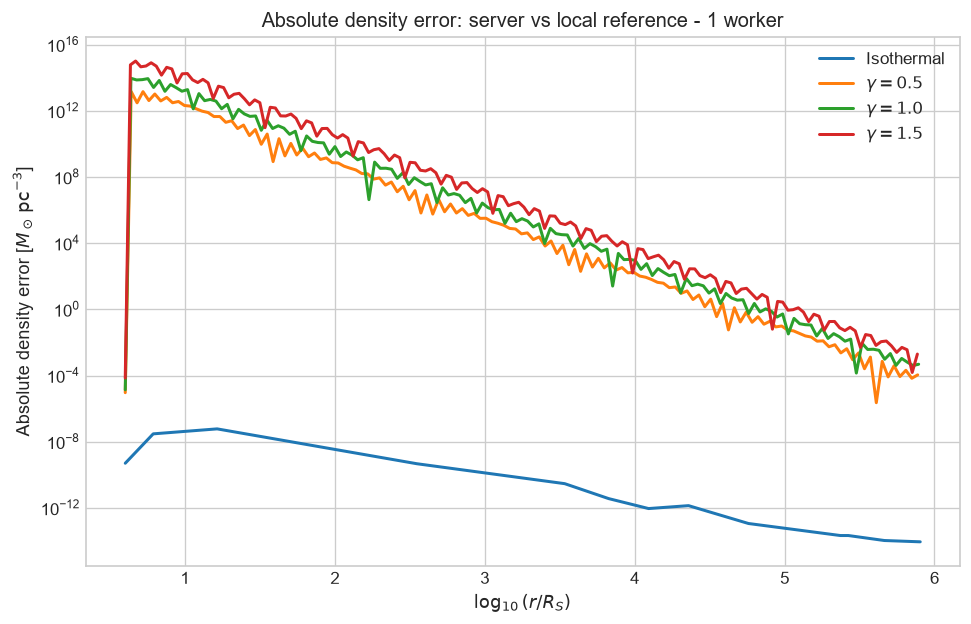

Exactly zero error points (masked only for logarithmic display):
  Isothermal: 186
  $\gamma = 0.5$: 0
  $\gamma = 1.0$: 0
  $\gamma = 1.5$: 0


In [14]:
plot_absolute_errors(1)

## Absolute error - 8 workers

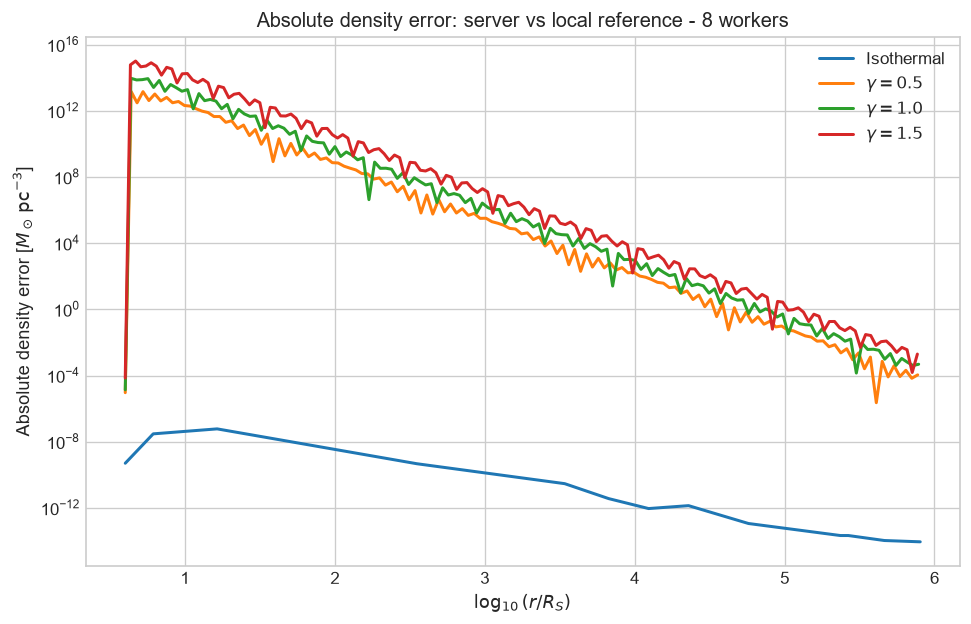

Exactly zero error points (masked only for logarithmic display):
  Isothermal: 186
  $\gamma = 0.5$: 0
  $\gamma = 1.0$: 0
  $\gamma = 1.5$: 0


In [15]:
plot_absolute_errors(8)

## Absolute error - 16 workers

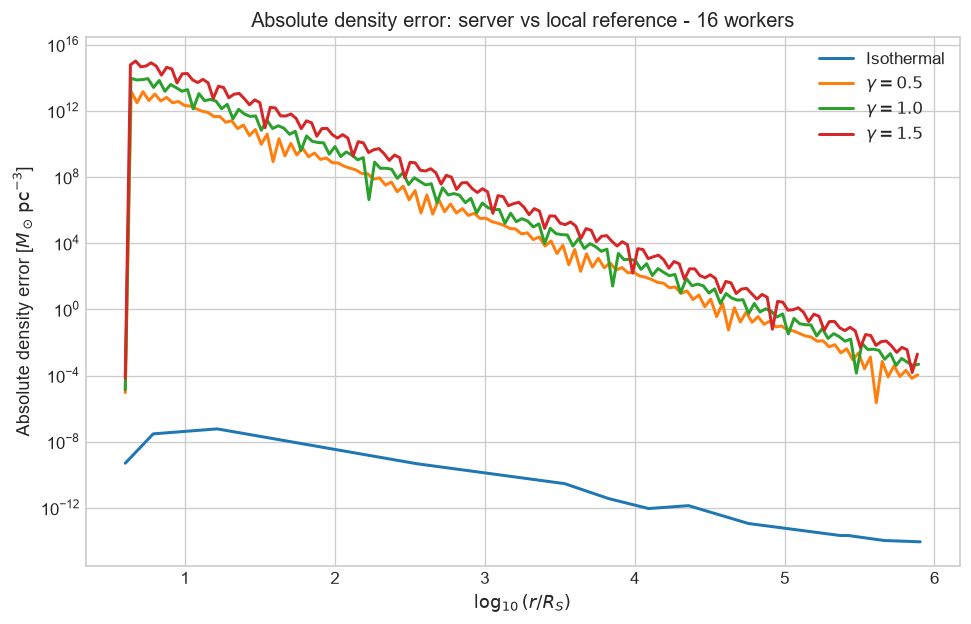

Exactly zero error points (masked only for logarithmic display):
  Isothermal: 186
  $\gamma = 0.5$: 0
  $\gamma = 1.0$: 0
  $\gamma = 1.5$: 0


In [16]:
plot_absolute_errors(16)

## Absolute error - 32 workers

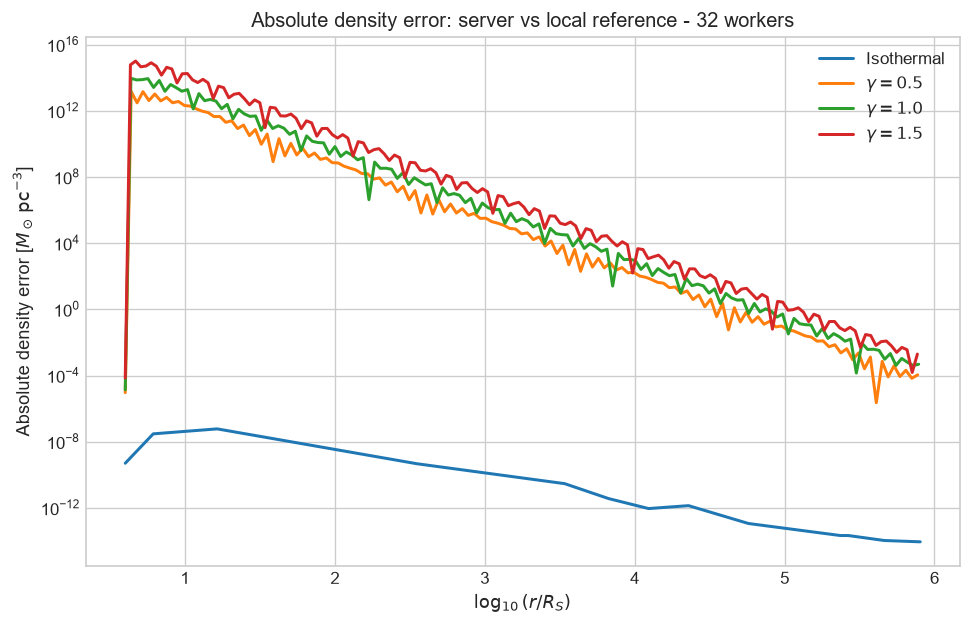

Exactly zero error points (masked only for logarithmic display):
  Isothermal: 186
  $\gamma = 0.5$: 0
  $\gamma = 1.0$: 0
  $\gamma = 1.5$: 0


In [17]:
plot_absolute_errors(32)

## Part F - Absolute-error metrics

Metrics are evaluated only at the compared points: all points for effectively identical meshes, or server points inside the common radial domain after interpolation of the local reference.

In [18]:
error_metrics = {}
for worker in workers:
    worker = int(worker)
    rows = []
    error_metrics[worker] = {}
    for label, _, _ in PROFILE_SPECS:
        result = validation_results[worker][label]
        error = result["abs_error"]
        metrics = {
            "maximum": float(np.max(error)),
            "mean": float(np.mean(error)),
            "median": float(np.median(error)),
            "rmse": float(np.sqrt(np.mean(np.square(error)))),
            "points": int(error.size),
            "interpolation": bool(result["interpolation_required"]),
        }
        error_metrics[worker][label] = metrics
        rows.append([
            label,
            f"{metrics['maximum']:.6e}",
            f"{metrics['mean']:.6e}",
            f"{metrics['median']:.6e}",
            f"{metrics['rmse']:.6e}",
            metrics["points"],
            metrics["interpolation"],
        ])

    display(Markdown(f"### {worker} worker{'s' if worker != 1 else ''}"))
    display_markdown_table(
        [
            "Profile",
            "Maximum absolute error",
            "Mean absolute error",
            "Median absolute error",
            "RMSE",
            "Number of compared points",
            "Interpolation required?",
        ],
        rows,
    )

### 1 worker

| Profile | Maximum absolute error | Mean absolute error | Median absolute error | RMSE | Number of compared points | Interpolation required? |
| --- | --- | --- | --- | --- | --- | --- |
| Isothermal | 5.960464e-08 | 5.451634e-10 | 0.000000e+00 | 4.893007e-09 | 200 | False |
| $\gamma = 0.5$ | 1.459913e+13 | 5.376028e+11 | 3.666986e+04 | 2.187557e+12 | 135 | True |
| $\gamma = 1.0$ | 9.274685e+13 | 4.050466e+12 | 1.564353e+05 | 1.599531e+13 | 141 | True |
| $\gamma = 1.5$ | 1.020197e+15 | 3.612175e+13 | 1.047113e+06 | 1.432879e+14 | 154 | True |

### 8 workers

| Profile | Maximum absolute error | Mean absolute error | Median absolute error | RMSE | Number of compared points | Interpolation required? |
| --- | --- | --- | --- | --- | --- | --- |
| Isothermal | 5.960464e-08 | 5.451634e-10 | 0.000000e+00 | 4.893007e-09 | 200 | False |
| $\gamma = 0.5$ | 1.459913e+13 | 5.376028e+11 | 3.666986e+04 | 2.187557e+12 | 135 | True |
| $\gamma = 1.0$ | 9.274685e+13 | 4.050466e+12 | 1.564353e+05 | 1.599531e+13 | 141 | True |
| $\gamma = 1.5$ | 1.020197e+15 | 3.612175e+13 | 1.047113e+06 | 1.432879e+14 | 154 | True |

### 16 workers

| Profile | Maximum absolute error | Mean absolute error | Median absolute error | RMSE | Number of compared points | Interpolation required? |
| --- | --- | --- | --- | --- | --- | --- |
| Isothermal | 5.960464e-08 | 5.451634e-10 | 0.000000e+00 | 4.893007e-09 | 200 | False |
| $\gamma = 0.5$ | 1.459913e+13 | 5.376028e+11 | 3.666986e+04 | 2.187557e+12 | 135 | True |
| $\gamma = 1.0$ | 9.274685e+13 | 4.050466e+12 | 1.564353e+05 | 1.599531e+13 | 141 | True |
| $\gamma = 1.5$ | 1.020197e+15 | 3.612175e+13 | 1.047113e+06 | 1.432879e+14 | 154 | True |

### 32 workers

| Profile | Maximum absolute error | Mean absolute error | Median absolute error | RMSE | Number of compared points | Interpolation required? |
| --- | --- | --- | --- | --- | --- | --- |
| Isothermal | 5.960464e-08 | 5.451634e-10 | 0.000000e+00 | 4.893007e-09 | 200 | False |
| $\gamma = 0.5$ | 1.459913e+13 | 5.376028e+11 | 3.666986e+04 | 2.187557e+12 | 135 | True |
| $\gamma = 1.0$ | 9.274685e+13 | 4.050466e+12 | 1.564353e+05 | 1.599531e+13 | 141 | True |
| $\gamma = 1.5$ | 1.020197e+15 | 3.612175e+13 | 1.047113e+06 | 1.432879e+14 | 154 | True |

## Part G - Server-to-server consistency

The 1-worker server result is the reference here. Radial grids are checked before any density comparison. Density equality is reported only when the corresponding meshes are compatible.

In [19]:
worker_consistency = []
reference_server = server_profiles[1]

for worker in (8, 16, 32):
    candidate = server_profiles[worker]
    for label, radius_key, density_key in PROFILE_SPECS:
        r_reference = reference_server[radius_key]
        r_candidate = candidate[radius_key]
        mesh_equal = np.array_equal(r_candidate, r_reference)
        mesh_close = (
            r_candidate.shape == r_reference.shape
            and np.allclose(r_candidate, r_reference, rtol=GRID_RTOL, atol=0.0)
        )

        if mesh_close:
            rho_reference = reference_server[density_key]
            rho_candidate = candidate[density_key]
            density_equal = np.array_equal(rho_candidate, rho_reference)
            density_close = np.allclose(rho_candidate, rho_reference, rtol=1e-12, atol=0.0)
            max_abs_difference = float(np.max(np.abs(rho_candidate - rho_reference)))
        else:
            density_equal = "not compared"
            density_close = "not compared"
            max_abs_difference = "not compared"

        worker_consistency.append({
            "worker": worker,
            "profile": label,
            "mesh_equal": mesh_equal,
            "mesh_close": mesh_close,
            "density_equal": density_equal,
            "density_close": density_close,
            "max_abs_difference": max_abs_difference,
        })

consistency_rows = []
for row in worker_consistency:
    max_difference = row["max_abs_difference"]
    if isinstance(max_difference, float):
        max_difference = f"{max_difference:.6e}"
    consistency_rows.append([
        f"{row['worker']} vs 1",
        row["profile"],
        row["mesh_equal"],
        row["mesh_close"],
        row["density_equal"],
        row["density_close"],
        max_difference,
    ])

display_markdown_table(
    [
        "Comparison",
        "Profile",
        "Mesh array_equal",
        "Mesh allclose",
        "Density array_equal",
        "Density allclose",
        "Maximum absolute difference",
    ],
    consistency_rows,
)

| Comparison | Profile | Mesh array_equal | Mesh allclose | Density array_equal | Density allclose | Maximum absolute difference |
| --- | --- | --- | --- | --- | --- | --- |
| 8 vs 1 | Isothermal | True | True | True | True | 0.000000e+00 |
| 8 vs 1 | $\gamma = 0.5$ | True | True | True | True | 0.000000e+00 |
| 8 vs 1 | $\gamma = 1.0$ | True | True | True | True | 0.000000e+00 |
| 8 vs 1 | $\gamma = 1.5$ | True | True | True | True | 0.000000e+00 |
| 16 vs 1 | Isothermal | True | True | True | True | 0.000000e+00 |
| 16 vs 1 | $\gamma = 0.5$ | True | True | True | True | 0.000000e+00 |
| 16 vs 1 | $\gamma = 1.0$ | True | True | True | True | 0.000000e+00 |
| 16 vs 1 | $\gamma = 1.5$ | True | True | True | True | 0.000000e+00 |
| 32 vs 1 | Isothermal | True | True | True | True | 0.000000e+00 |
| 32 vs 1 | $\gamma = 0.5$ | True | True | True | True | 0.000000e+00 |
| 32 vs 1 | $\gamma = 1.0$ | True | True | True | True | 0.000000e+00 |
| 32 vs 1 | $\gamma = 1.5$ | True | True | True | True | 0.000000e+00 |

## Part I - Interpretation

In [20]:
scaling_lines = [
    f"- **{int(n)} worker{'s' if n != 1 else ''}:** runtime {runtime:.3f} s, speedup {s:.3f}, efficiency {e:.1%}."
    for n, runtime, s, e in zip(workers, total_runtimes, speedup, parallel_efficiency)
]
runtime_reduction = 1.0 - total_runtimes[-1] / total_runtimes[0]

profile_maxima = {}
for label, _, _ in PROFILE_SPECS:
    profile_maxima[label] = max(
        error_metrics[int(worker)][label]["maximum"] for worker in workers
    )
validation_lines = [
    f"- **{label}:** largest absolute error across the four server runs = {value:.6e} "
    r"$M_\odot\,\mathrm{pc}^{-3}$."
    for label, value in profile_maxima.items()
]
all_server_values_exact = all(
    row["mesh_equal"] is True and row["density_equal"] is True
    for row in worker_consistency
)
interpolated_labels = [
    label
    for label, _, _ in PROFILE_SPECS
    if validation_results[1][label]["interpolation_required"]
]

display(Markdown(
    "## Performance\n\n"
    + "\n".join(scaling_lines)
    + f"\n\nThe 32-worker run reduces total runtime by {runtime_reduction:.1%} relative to the "
      "one-worker multiprocessing baseline. Runtime continues to decrease as workers are added, while "
      "parallel efficiency declines, showing diminishing returns. Because the server was shared and had a "
      "load average near 52-58, scheduler contention and concurrent work may influence the measured scaling; "
      "these data do not isolate a dedicated-machine limit.\n\n"
    "## Numerical validation\n\n"
    + "\n".join(validation_lines)
    + f"\n\nProfiles requiring interpolation because the local and server meshes differ: "
      f"{', '.join(interpolated_labels) if interpolated_labels else 'none'}. "
      "Interpolation is only a mesh-alignment operation; the reported errors are differences in linear density. "
    + (
        "The 8-, 16-, and 32-worker server files have exactly equal meshes and density arrays relative to "
        "the 1-worker server file. For these saved results, there is no observed worker-count-dependent "
        "rounding difference. "
        if all_server_values_exact
        else
        "At least one server-to-server comparison is not exactly equal; consult the consistency table to "
        "separate mesh compatibility from density differences. "
      )
    + "Differences from the local reference should not automatically be interpreted as server errors. The "
      "reference and server files were generated in different numerical environments and, for the cuspidal "
      "profiles, on different radial meshes. The available files alone do not identify a unique cause for "
      "any remaining discrepancy."
))

## Performance

- **1 worker:** runtime 2810.472 s, speedup 1.000, efficiency 100.0%.
- **8 workers:** runtime 394.534 s, speedup 7.124, efficiency 89.0%.
- **16 workers:** runtime 260.417 s, speedup 10.792, efficiency 67.5%.
- **32 workers:** runtime 163.098 s, speedup 17.232, efficiency 53.8%.

The 32-worker run reduces total runtime by 94.2% relative to the one-worker multiprocessing baseline. Runtime continues to decrease as workers are added, while parallel efficiency declines, showing diminishing returns. Because the server was shared and had a load average near 52-58, scheduler contention and concurrent work may influence the measured scaling; these data do not isolate a dedicated-machine limit.

## Numerical validation

- **Isothermal:** largest absolute error across the four server runs = 5.960464e-08 $M_\odot\,\mathrm{pc}^{-3}$.
- **$\gamma = 0.5$:** largest absolute error across the four server runs = 1.459913e+13 $M_\odot\,\mathrm{pc}^{-3}$.
- **$\gamma = 1.0$:** largest absolute error across the four server runs = 9.274685e+13 $M_\odot\,\mathrm{pc}^{-3}$.
- **$\gamma = 1.5$:** largest absolute error across the four server runs = 1.020197e+15 $M_\odot\,\mathrm{pc}^{-3}$.

Profiles requiring interpolation because the local and server meshes differ: $\gamma = 0.5$, $\gamma = 1.0$, $\gamma = 1.5$. Interpolation is only a mesh-alignment operation; the reported errors are differences in linear density. The 8-, 16-, and 32-worker server files have exactly equal meshes and density arrays relative to the 1-worker server file. For these saved results, there is no observed worker-count-dependent rounding difference. Differences from the local reference should not automatically be interpreted as server errors. The reference and server files were generated in different numerical environments and, for the cuspidal profiles, on different radial meshes. The available files alone do not identify a unique cause for any remaining discrepancy.